# Notebook tổng hợp figure cho paper

Notebook này được thiết kế để **vẽ và lưu toàn bộ các đồ thị có thể đưa vào paper** cho đề tài **Robust Reward Design for MDPs in Cybersecurity: A Probabilistic Attack-Graph Case Study**.

## Nhóm figure được hỗ trợ
1. Hình attack-graph cho các case nhỏ.
2. So sánh optimistic vs pessimistic value giữa standard và robust.
3. Robustness gap và margin $c^*$.
4. Xác suất attacker vào true goal / decoy dưới bounded rationality.
5. Runtime comparison giữa exact standard, exact robust và scalable heuristic.
6. Profile phân bổ reward tại các intervention sites.
7. Budget sweep: $v_1^*$, pessimistic value, margin $c^*$ theo ngân sách $C$.
8. Tau sweep: ảnh hưởng của bounded rationality lên defender value, true-goal probability, decoy probability.
9. Reward-perception perturbation sweep: độ nhạy theo nhiễu $\epsilon$ trong chuẩn $L_1$.
10. Intervention ranking cho large graphs.
11. Scalability figure cho graph lớn.
12. Bubble/scatter figure tóm tắt benchmark toàn hệ thống.

## Cách dùng nhanh
- Giải nén `robust_reward_design_journal_production_suite.zip`.
- Mở notebook này trong cùng thư mục cha với `robust_reward_design_lab`, hoặc đặt biến môi trường `RRD_ROOT` trỏ tới thư mục repo.
- Chạy tuần tự từ trên xuống dưới.

Mọi hình sẽ được lưu vào thư mục `paper_notebook_outputs/figures/` trong repo.


In [1]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
  Using cached pip-26.1.1-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 26.0.1
    Uninstalling pip-26.0.1:
      Successfully uninstalled pip-26.0.1
Defaulting to user installation because normal site-packages is not writeable
  Using cached python_docx-1.2.0-py3-none-any.whl.metadata (2.0 kB)
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
    --------------------------------------- 0.3/16.4 MB ? eta -:--:--
   --------- ------------------------------ 3.9/16.4 MB 18.1 MB/s eta 0:00:01
   -------------------------- ------------- 11.0/16.4 MB 32.8 MB/s eta 0:00:01
   ---------------------------------------- 16.4/16.4 MB 33.3 MB/s  0:00:00
Using cached python_docx-1.2.0-py3-none-any.whl (252 kB)
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   --------------------

In [2]:
from __future__ import annotations

import ast
import json
import math
import os
import sys
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display, Markdown, Image

plt.rcParams['figure.dpi'] = 140
plt.rcParams['savefig.dpi'] = 220
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


def detect_repo_root() -> Path:
    candidates = []
    env_root = os.environ.get('RRD_ROOT')
    if env_root:
        candidates.append(Path(env_root))
    cwd = Path.cwd()
    candidates.extend([
        cwd,
        cwd / 'robust_reward_design_lab',
        cwd.parent / 'robust_reward_design_lab',
        Path('/mnt/data/robust_reward_design_lab'),
        Path.home() / 'robust_reward_design_lab',
    ])
    for c in candidates:
        if (c / 'src').exists() and (c / 'configs').exists():
            return c.resolve()
    zip_candidates = [
        cwd / 'robust_reward_design_journal_production_suite.zip',
        cwd.parent / 'robust_reward_design_journal_production_suite.zip',
        Path('/mnt/data/robust_reward_design_journal_production_suite.zip'),
    ]
    for z in zip_candidates:
        if z.exists():
            target = z.parent / 'robust_reward_design_lab'
            if not target.exists():
                with zipfile.ZipFile(z, 'r') as zf:
                    zf.extractall(z.parent)
            if (target / 'src').exists():
                return target.resolve()
    raise FileNotFoundError('Không tìm thấy robust_reward_design_lab. Hãy giải nén suite hoặc đặt biến môi trường RRD_ROOT.')


ROOT = detect_repo_root()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

FIG_DIR = ROOT / 'paper_notebook_outputs' / 'figures'
DATA_DIR = ROOT / 'paper_notebook_outputs' / 'data'
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT =', ROOT)
print('FIG_DIR =', FIG_DIR)
print('DATA_DIR =', DATA_DIR)


ROOT = D:\robust_reward_design_journal_production_suite\robust_reward_design_lab
FIG_DIR = D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\paper_notebook_outputs\figures
DATA_DIR = D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\paper_notebook_outputs\data


In [3]:
from mdp_model import load_mdp
from standard_reward_design import solve_standard_reward_design
from robust_reward_design import solve_max_margin_reward_design
from evaluation import (
    optimistic_and_pessimistic_values,
    soft_response_summary,
    reward_perception_sweep,
)
from scalable_heuristics import run_scalable_pipeline
from intervention_design import score_interventions
from visualization import build_networkx_graph
import networkx as nx

SMALL_CASES = [
    'paper_style_attack_graph.json',
    'branching_enterprise_graph.json',
    'lateral_movement_graph.json',
]
LARGE_CASES = [
    'large_enterprise_64.json',
    'large_enterprise_120.json',
]

RESULTS_CSV = ROOT / 'results' / 'experiment_summary.csv'
JOURNAL_CSV = ROOT / 'results_journal' / 'combined_benchmark_summary.csv'
BUDGET_JSON = ROOT / 'results' / 'budget_sweep' / 'budget_sweep.json'

exp_df = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else pd.DataFrame()
bench_df = pd.read_csv(JOURNAL_CSV) if JOURNAL_CSV.exists() else pd.DataFrame()


def savefig(name: str, tight: bool = True):
    path = FIG_DIR / name
    if tight:
        plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    print('Saved:', path)
    return path


def parse_alloc(x):
    if isinstance(x, dict):
        return x
    if pd.isna(x):
        return {}
    if isinstance(x, str):
        return ast.literal_eval(x)
    return dict(x)


def get_case_mdp(case_name: str):
    return load_mdp(ROOT / 'configs' / f'{case_name}.json')


def cache_csv(path: Path, builder):
    if path.exists():
        return pd.read_csv(path)
    df = builder()
    df.to_csv(path, index=False)
    print('Cached:', path)
    return df


def ensure_journal_summary(time_limit: int = 60):
    if JOURNAL_CSV.exists():
        return pd.read_csv(JOURNAL_CSV)
    rows = []
    for name in SMALL_CASES:
        mdp = load_mdp(ROOT / 'configs' / name)
        std = solve_standard_reward_design(mdp, time_limit_seconds=time_limit)
        rob = solve_max_margin_reward_design(mdp, v1_star=std.v1_star, time_limit_seconds=time_limit)
        std_vals = optimistic_and_pessimistic_values(mdp, std.x_milp)
        rob_vals = optimistic_and_pessimistic_values(mdp, rob.x_ip)
        std_soft = soft_response_summary(mdp, std.x_milp, tau=0.05)
        rob_soft = soft_response_summary(mdp, rob.x_ip, tau=0.05)
        rows.extend([
            {
                'case_name': mdp.name, 'mode': 'exact_standard', 'num_states': len(mdp.states),
                'num_interventions': len(mdp.interventions), 'optimistic_value': std_vals.defender_optimistic_value,
                'pessimistic_value': std_vals.defender_pessimistic_value, 'margin': 0.0,
                'tau05_true_goal_prob': std_soft.true_goal_probability, 'tau05_decoy_prob': std_soft.decoy_probability,
                'runtime_seconds': std.runtime_seconds,
            },
            {
                'case_name': mdp.name, 'mode': 'exact_robust', 'num_states': len(mdp.states),
                'num_interventions': len(mdp.interventions), 'optimistic_value': rob_vals.defender_optimistic_value,
                'pessimistic_value': rob_vals.defender_pessimistic_value, 'margin': rob.c_star,
                'tau05_true_goal_prob': rob_soft.true_goal_probability, 'tau05_decoy_prob': rob_soft.decoy_probability,
                'runtime_seconds': rob.runtime_seconds,
            }
        ])
    for name in LARGE_CASES:
        mdp = load_mdp(ROOT / 'configs' / name)
        res = run_scalable_pipeline(mdp)
        rows.append({
            'case_name': mdp.name, 'mode': 'scalable_heuristic', 'num_states': len(mdp.states),
            'num_interventions': len(mdp.interventions), 'optimistic_value': res.optimistic_value,
            'pessimistic_value': res.pessimistic_value, 'margin': res.empirical_margin,
            'tau05_true_goal_prob': res.tau05_true_goal_prob, 'tau05_decoy_prob': res.tau05_decoy_prob,
            'runtime_seconds': res.runtime_seconds,
        })
    df = pd.DataFrame(rows)
    JOURNAL_CSV.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(JOURNAL_CSV, index=False)
    return df


bench_df = ensure_journal_summary()
display(bench_df)


,case_name,mode,num_states,num_interventions,optimistic_value,pessimistic_value,margin,tau05_true_goal_prob,tau05_decoy_prob,runtime_seconds
0,paper_style_attack_graph,exact_standard,13,2,0.676469,0.329232,0.0,0.355469,0.636719,0.000000
1,paper_style_attack_graph,exact_robust,13,2,0.676469,0.676468,0.4,0.272915,0.718224,0.000000
2,branching_enterprise_graph,exact_standard,14,3,0.712975,0.342950,0.0,0.362164,0.629205,0.000000
3,branching_enterprise_graph,exact_robust,14,3,0.712975,0.342950,0.0,0.362164,0.629205,0.000000
4,lateral_movement_graph,exact_standard,16,3,0.708508,0.629086,0.0,0.375216,0.614356,0.000000
5,lateral_movement_graph,exact_robust,16,3,0.708508,0.708507,0.4,0.238302,0.750673,0.000000
6,large_enterprise_64,scalable_heuristic,65,10,0.799304,0.799264,0.5,0.001602,0.995329,11.255031
7,large_enterprise_120,scalable_heuristic,121,16,0.799304,0.799304,0.5,0.000029,0.999968,9.332089


## 1. Hình attack-graph cho các case nhỏ

Saved: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\paper_notebook_outputs\figures\fig01_attack_graph_panel.png


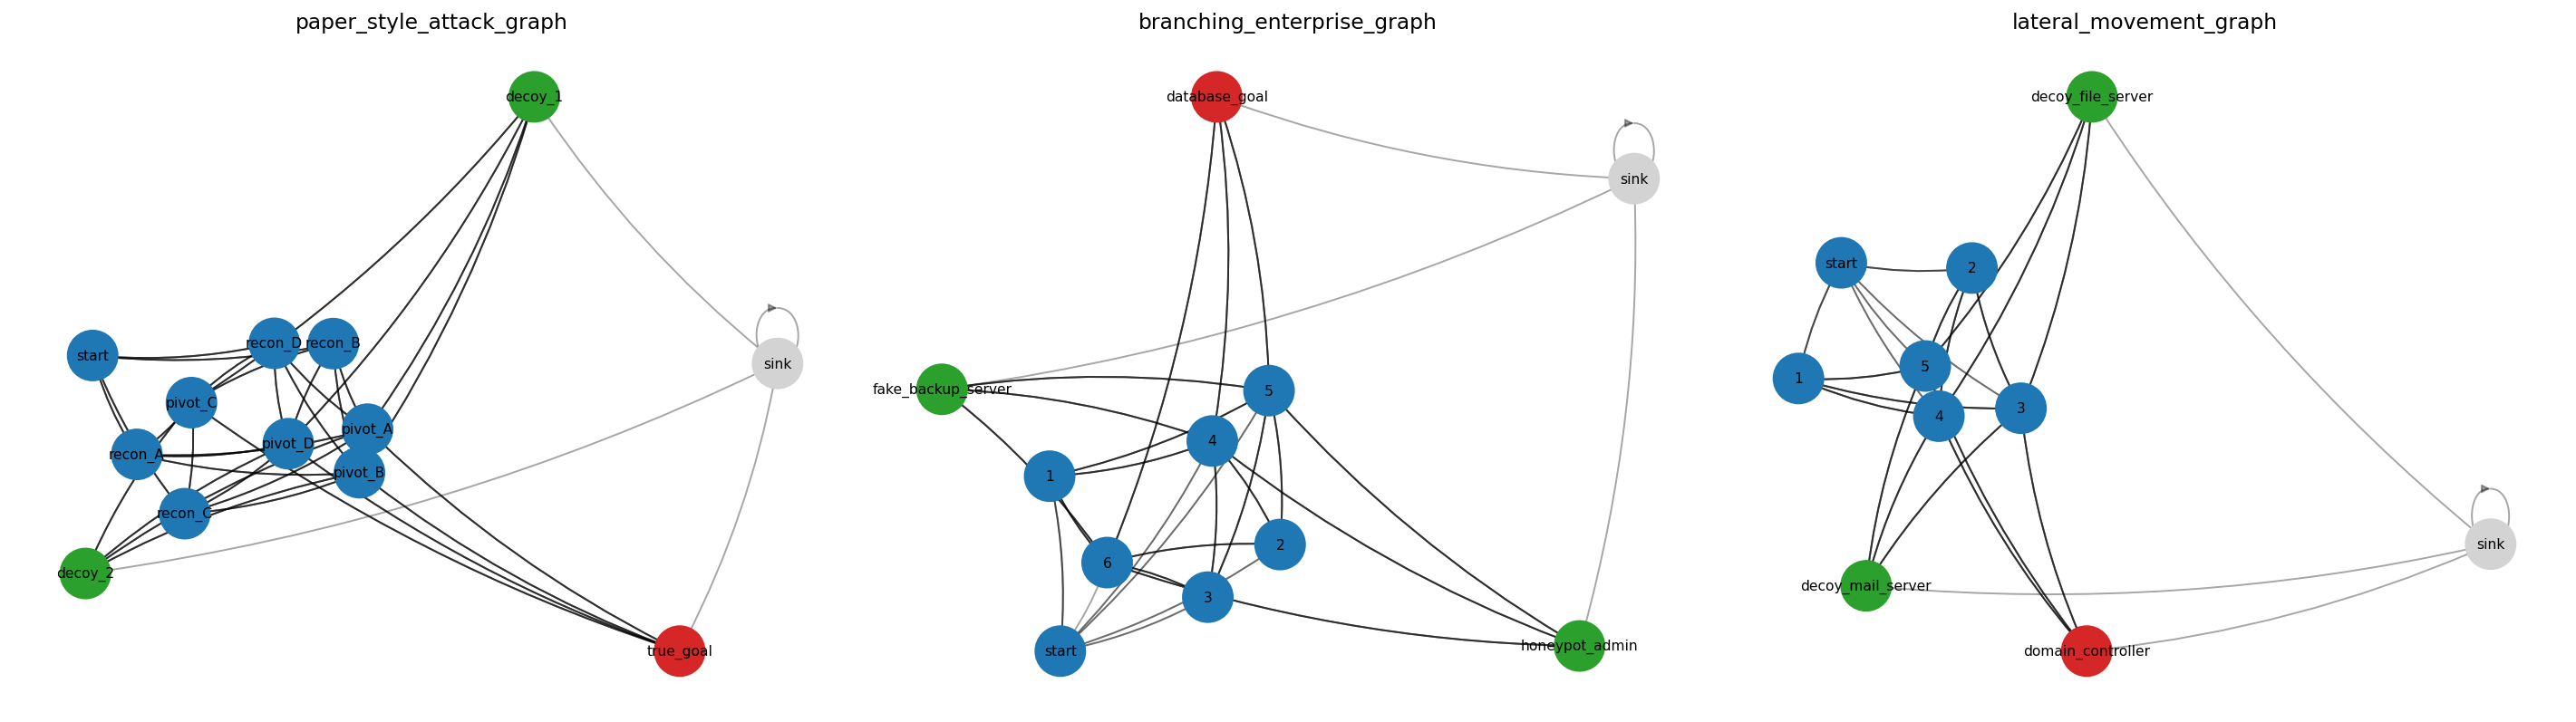

In [4]:
small_case_names = [Path(x).stem for x in SMALL_CASES]
fig, axes = plt.subplots(1, len(small_case_names), figsize=(6.8 * len(small_case_names), 5.8))
if len(small_case_names) == 1:
    axes = [axes]

for ax, case_name in zip(axes, small_case_names):
    mdp = get_case_mdp(case_name)
    G = build_networkx_graph(mdp)
    pos = nx.spring_layout(G, seed=7)
    node_colors = []
    for n in G.nodes:
        if n in mdp.true_goals:
            node_colors.append('tab:red')
        elif n in mdp.decoy_sites:
            node_colors.append('tab:green')
        elif n == mdp.sink_state:
            node_colors.append('lightgray')
        else:
            node_colors.append('tab:blue')
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800, ax=ax)
    nx.draw_networkx_labels(G, pos, labels={n: mdp.label(n) for n in G.nodes}, font_size=8, ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.35, arrows=True, connectionstyle='arc3,rad=0.08', ax=ax)
    ax.set_title(case_name)
    ax.axis('off')

savefig('fig01_attack_graph_panel.png')
plt.show()


## 2. Optimistic vs pessimistic value (standard vs robust)

Saved: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\paper_notebook_outputs\figures\fig02_optimistic_pessimistic_values.png


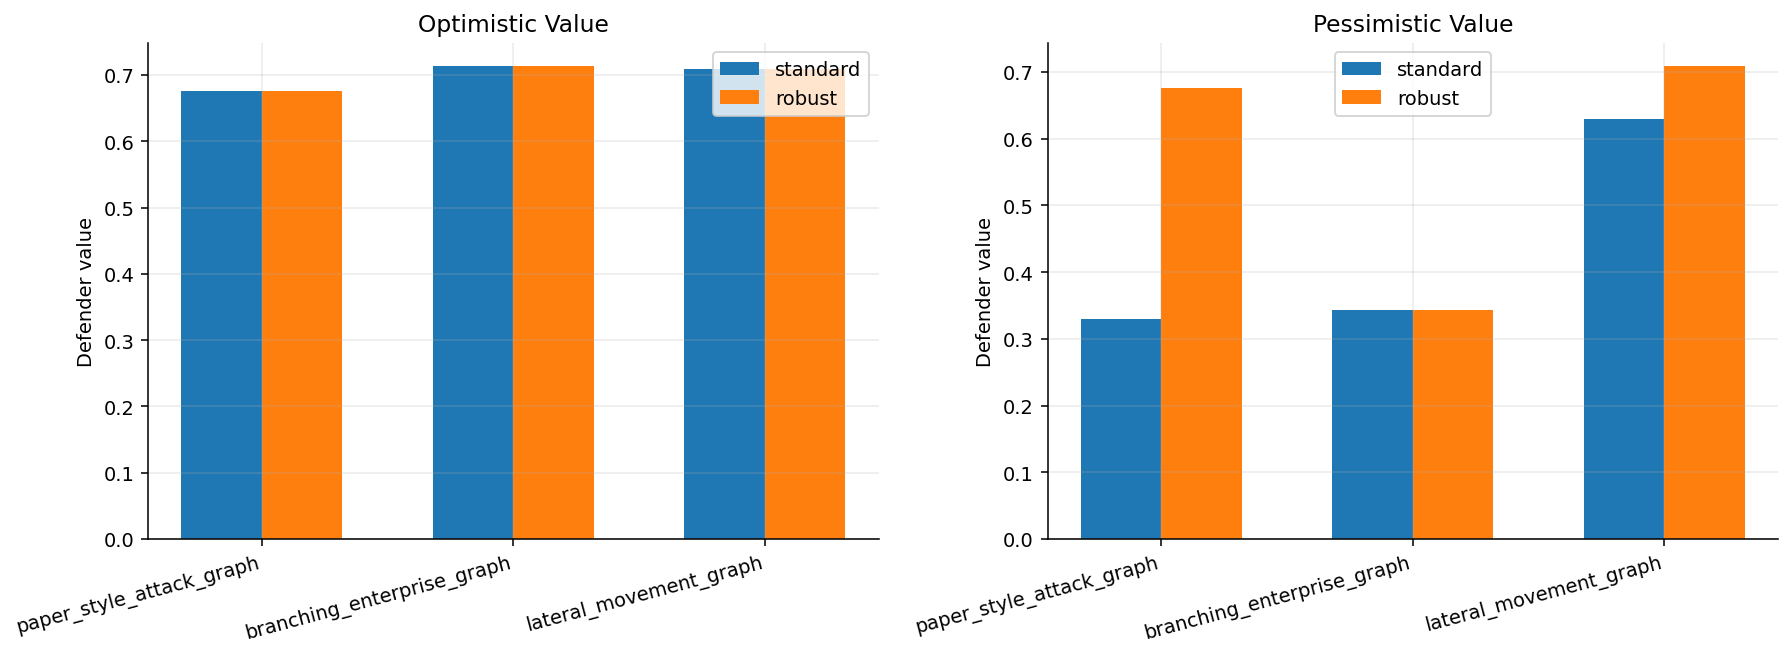

In [5]:
exact_df = bench_df[bench_df['mode'].isin(['exact_standard', 'exact_robust'])].copy()
case_order = exact_df['case_name'].drop_duplicates().tolist()
mode_order = ['exact_standard', 'exact_robust']
labels = ['standard', 'robust']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
width = 0.32
x = np.arange(len(case_order))

for j, metric in enumerate(['optimistic_value', 'pessimistic_value']):
    ax = axes[j]
    for i, mode in enumerate(mode_order):
        vals = [exact_df[(exact_df['case_name'] == c) & (exact_df['mode'] == mode)][metric].iloc[0] for c in case_order]
        ax.bar(x + (i - 0.5) * width, vals, width=width, label=labels[i])
    ax.set_xticks(x)
    ax.set_xticklabels(case_order, rotation=15, ha='right')
    ax.set_ylabel('Defender value')
    ax.set_title(metric.replace('_', ' ').title())
    ax.legend()

savefig('fig02_optimistic_pessimistic_values.png')
plt.show()


## 3. Robustness gap và margin $c^*$

Saved: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\paper_notebook_outputs\figures\fig03_gap_and_margin.png


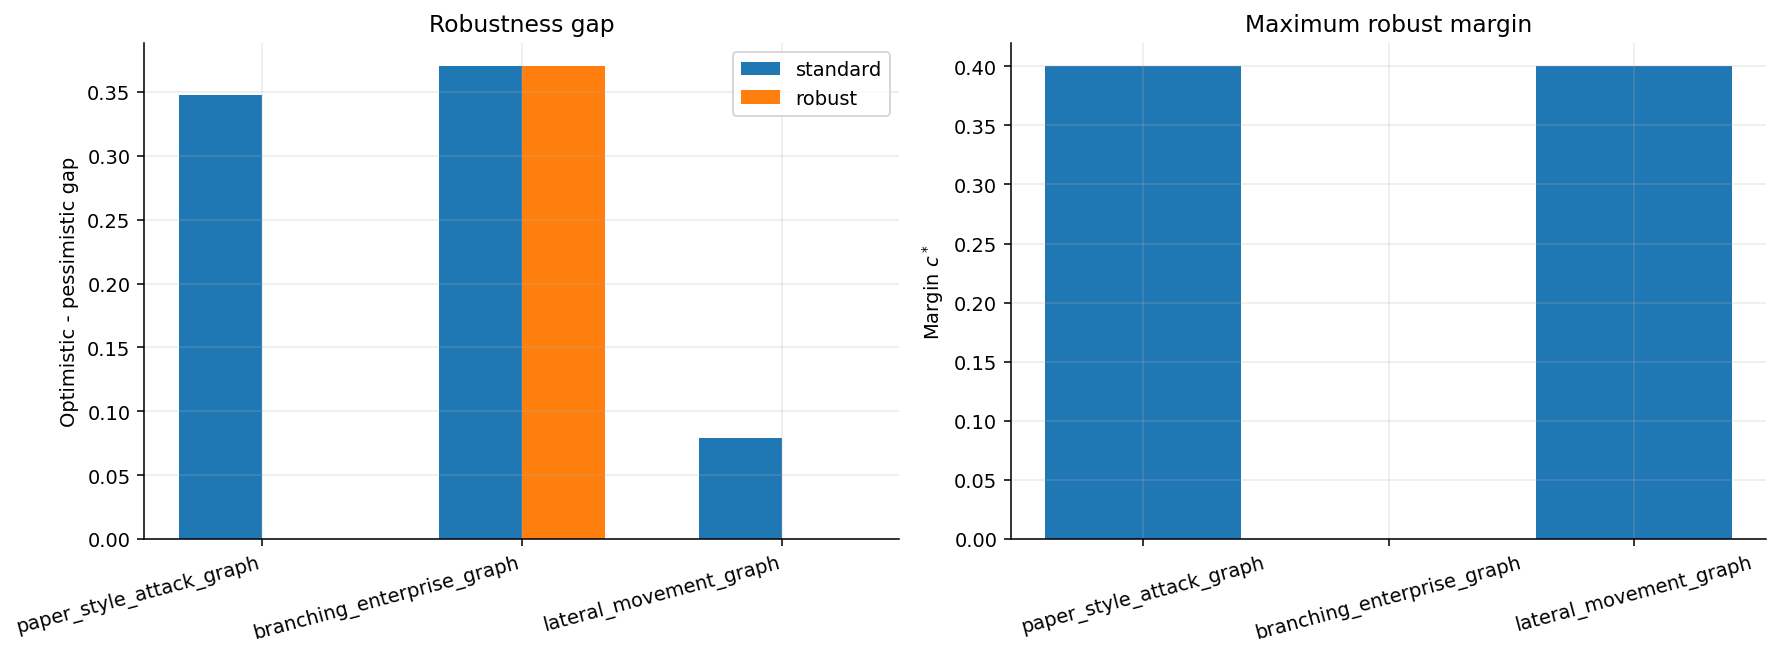

In [6]:
gap_df = exact_df.copy()
gap_df['gap'] = gap_df['optimistic_value'] - gap_df['pessimistic_value']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for i, mode in enumerate(mode_order):
    vals = [gap_df[(gap_df['case_name'] == c) & (gap_df['mode'] == mode)]['gap'].iloc[0] for c in case_order]
    axes[0].bar(x + (i - 0.5) * width, vals, width=width, label=labels[i])
axes[0].set_xticks(x)
axes[0].set_xticklabels(case_order, rotation=15, ha='right')
axes[0].set_ylabel('Optimistic - pessimistic gap')
axes[0].set_title('Robustness gap')
axes[0].legend()

margins = [gap_df[(gap_df['case_name'] == c) & (gap_df['mode'] == 'exact_robust')]['margin'].iloc[0] for c in case_order]
axes[1].bar(case_order, margins)
axes[1].set_ylabel('Margin $c^*$')
axes[1].set_title('Maximum robust margin')
axes[1].tick_params(axis='x', rotation=15)

savefig('fig03_gap_and_margin.png')
plt.show()


## 4. Bounded rationality: true-goal probability và decoy probability tại $\tau=0.05$

Saved: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\paper_notebook_outputs\figures\fig04_tau05_goal_vs_decoy.png


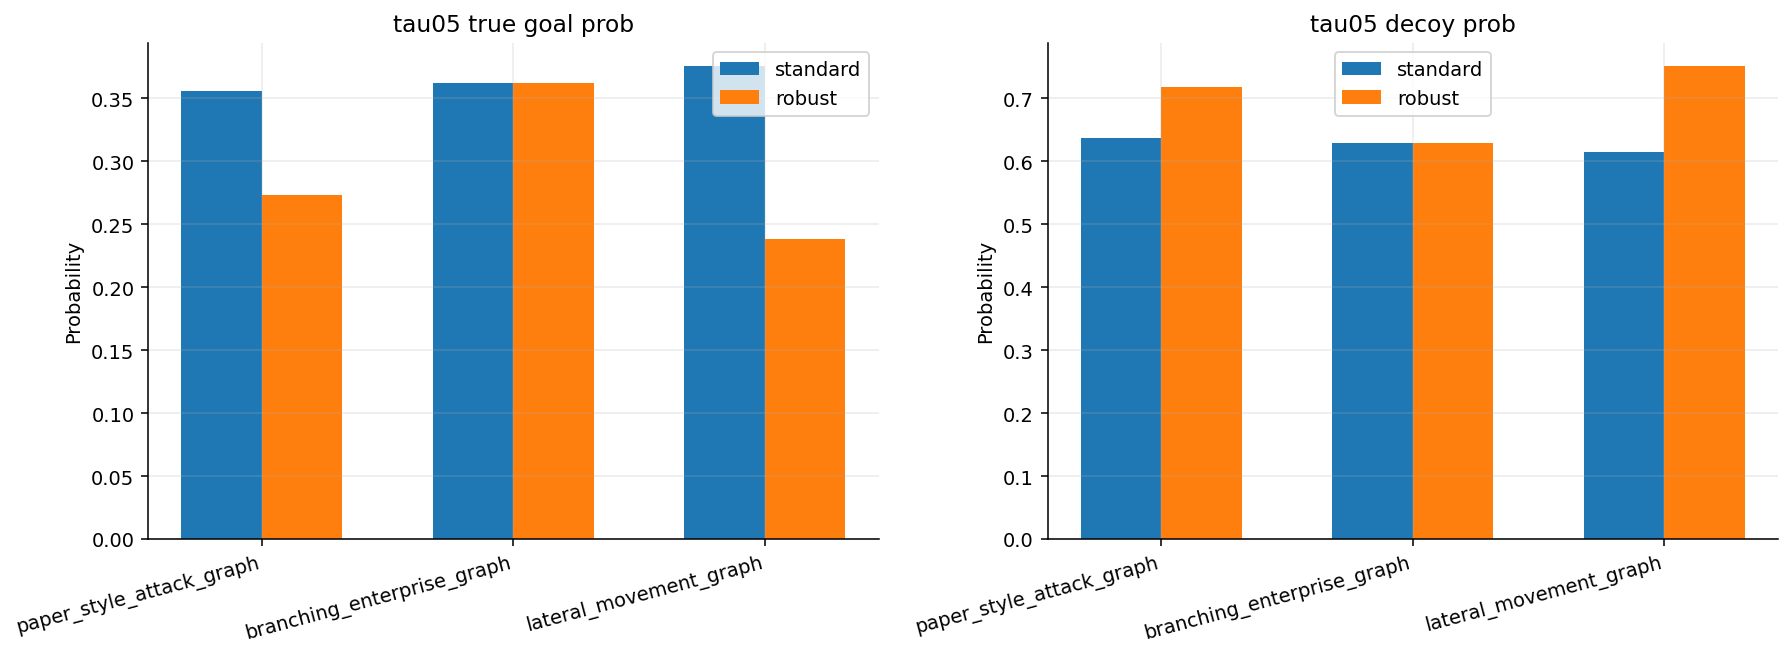

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for j, metric in enumerate(['tau05_true_goal_prob', 'tau05_decoy_prob']):
    ax = axes[j]
    for i, mode in enumerate(mode_order):
        vals = [exact_df[(exact_df['case_name'] == c) & (exact_df['mode'] == mode)][metric].iloc[0] for c in case_order]
        ax.bar(x + (i - 0.5) * width, vals, width=width, label=labels[i])
    ax.set_xticks(x)
    ax.set_xticklabels(case_order, rotation=15, ha='right')
    ax.set_ylabel('Probability')
    ax.set_title(metric.replace('_', ' '))
    ax.legend()

savefig('fig04_tau05_goal_vs_decoy.png')
plt.show()


## 5. Runtime comparison

Saved: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\paper_notebook_outputs\figures\fig05_runtime_scaling.png


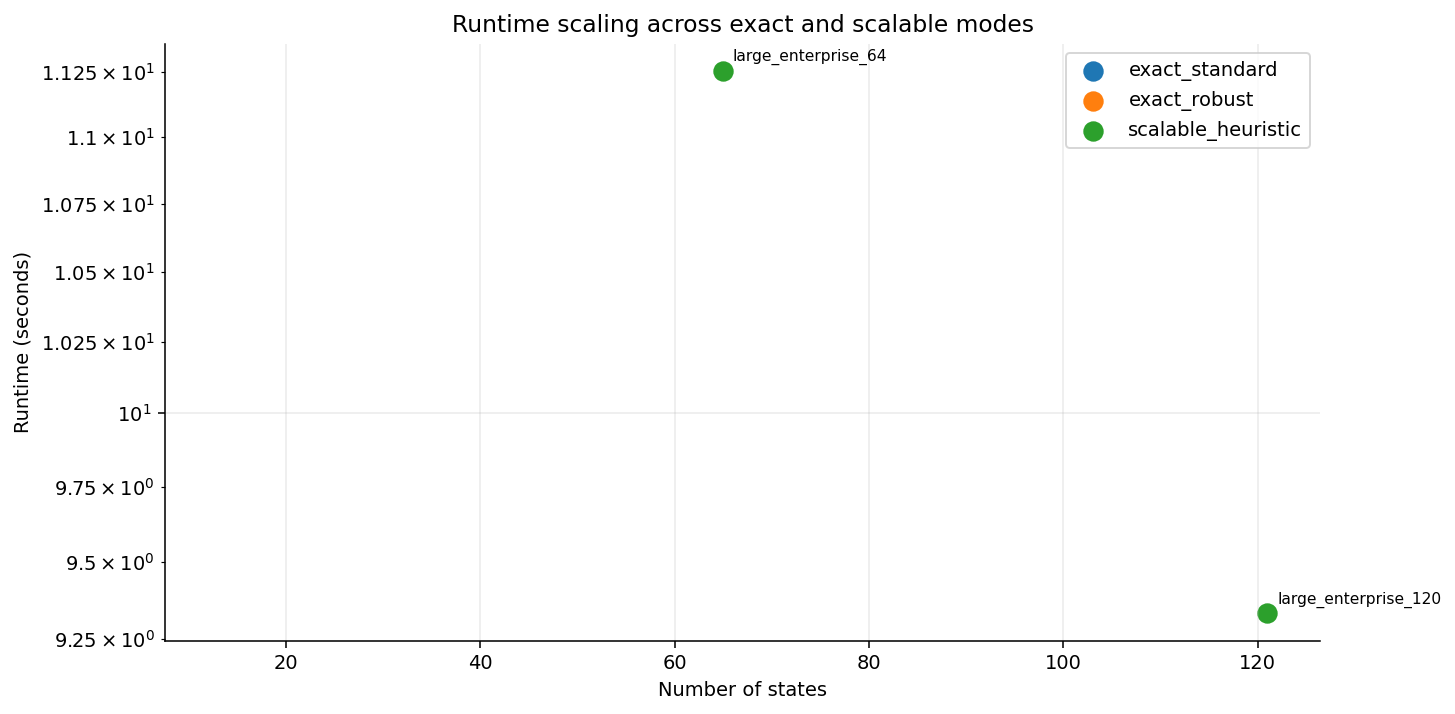

In [8]:
runtime_df = bench_df.copy()
fig, ax = plt.subplots(figsize=(10.5, 5.2))
for mode in runtime_df['mode'].unique():
    subset = runtime_df[runtime_df['mode'] == mode]
    ax.scatter(subset['num_states'], subset['runtime_seconds'], s=90, label=mode)
    for _, row in subset.iterrows():
        ax.annotate(row['case_name'], (row['num_states'], row['runtime_seconds']), xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Number of states')
ax.set_ylabel('Runtime (seconds)')
ax.set_yscale('log')
ax.set_title('Runtime scaling across exact and scalable modes')
ax.legend()
savefig('fig05_runtime_scaling.png')
plt.show()


## 6. Reward allocation profile tại intervention sites

Saved: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\paper_notebook_outputs\figures\fig06_allocation_profiles.png


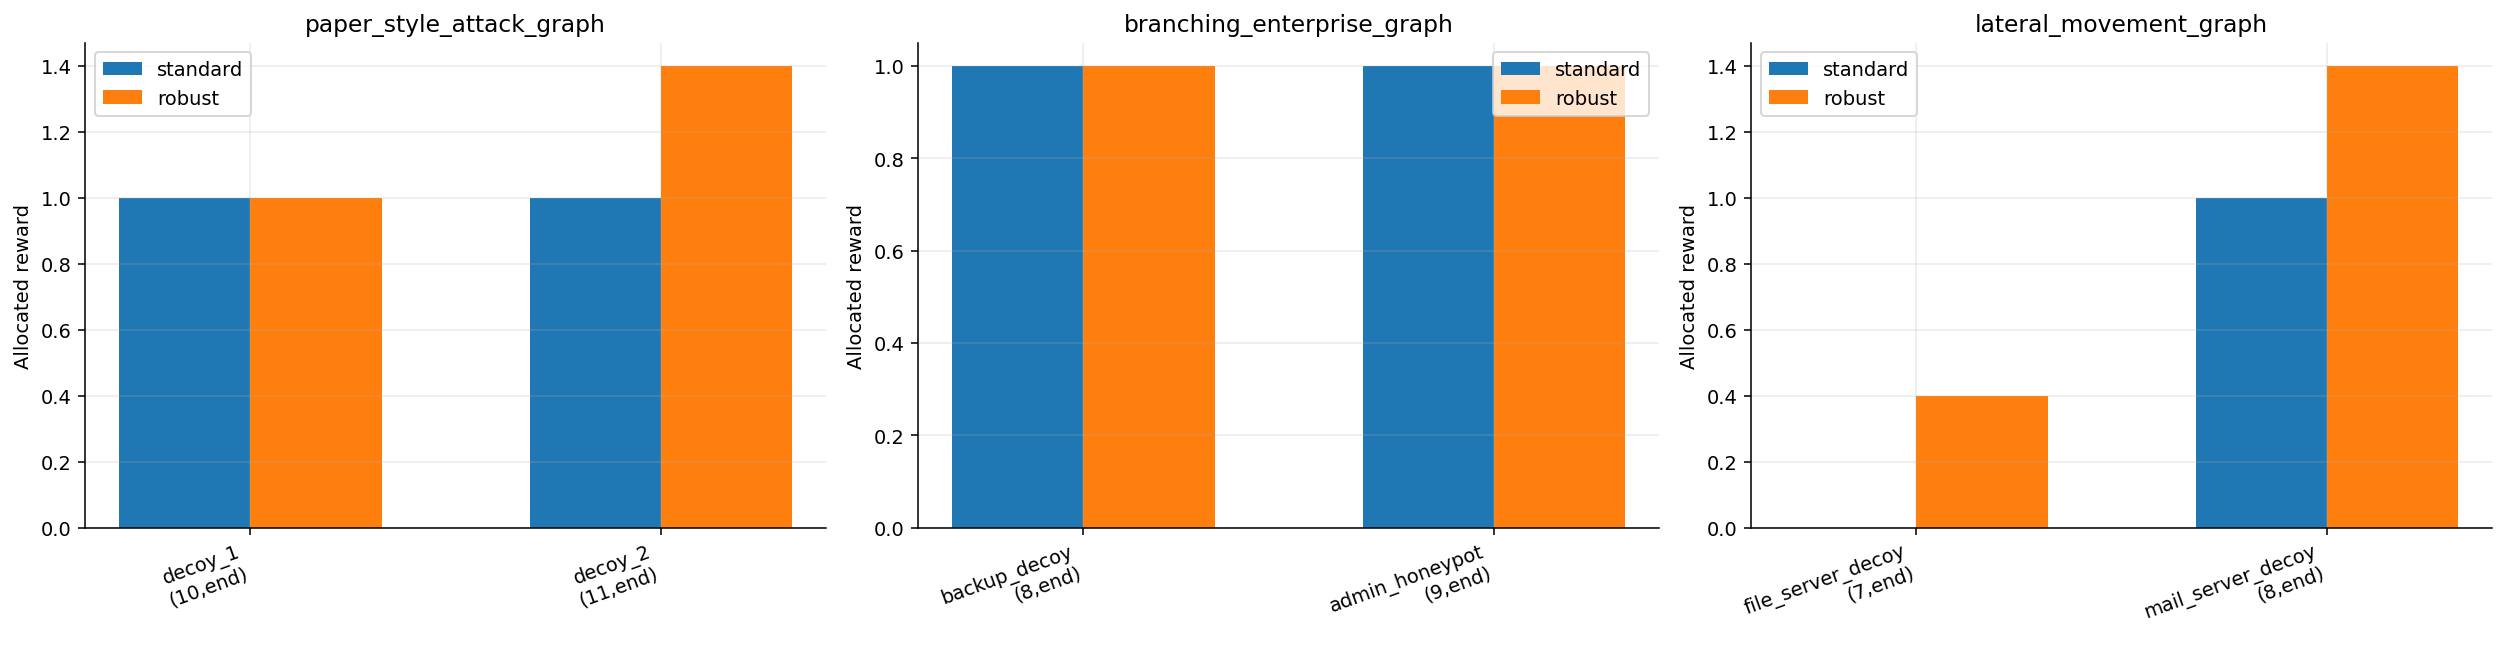

In [9]:
if exp_df.empty:
    display(Markdown('`results/experiment_summary.csv` chưa có. Hãy chạy `run_all_experiments.sh` trước nếu muốn figure này.`'))
else:
    fig, axes = plt.subplots(1, len(case_order), figsize=(6.0 * len(case_order), 4.8))
    if len(case_order) == 1:
        axes = [axes]
    for ax, case_name in zip(axes, case_order):
        row = exp_df[exp_df['case_name'] == case_name].iloc[0]
        mdp = get_case_mdp(case_name)
        site_names = [f"{it.name}\n({it.state},{it.action})" for it in mdp.interventions]
        std_alloc = parse_alloc(row['standard_x'])
        rob_alloc = parse_alloc(row['robust_x'])
        std_vals = [std_alloc.get(f'{it.state}|{it.action}', 0.0) for it in mdp.interventions]
        rob_vals = [rob_alloc.get(f'{it.state}|{it.action}', 0.0) for it in mdp.interventions]
        xi = np.arange(len(site_names))
        ax.bar(xi - width/2, std_vals, width=width, label='standard')
        ax.bar(xi + width/2, rob_vals, width=width, label='robust')
        ax.set_xticks(xi)
        ax.set_xticklabels(site_names, rotation=20, ha='right')
        ax.set_ylabel('Allocated reward')
        ax.set_title(case_name)
        ax.legend()
    savefig('fig06_allocation_profiles.png')
    plt.show()


## 7. Budget sweep cho case paper-style attack graph

,budget,v1_star,c_star,standard_runtime_seconds,robust_runtime_seconds
0,0.5,0.338663,0.000000,0.227825,1.509428
1,1.0,0.623312,0.066667,0.318916,4.250162
2,1.5,0.660179,0.100000,0.401541,3.496415
3,2.0,0.676469,0.000000,0.096740,0.913166
4,2.4,0.676469,0.400000,0.094107,1.236321
5,3.0,0.676469,1.000000,0.112917,1.744467


Saved: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\paper_notebook_outputs\figures\fig07_budget_sweep.png


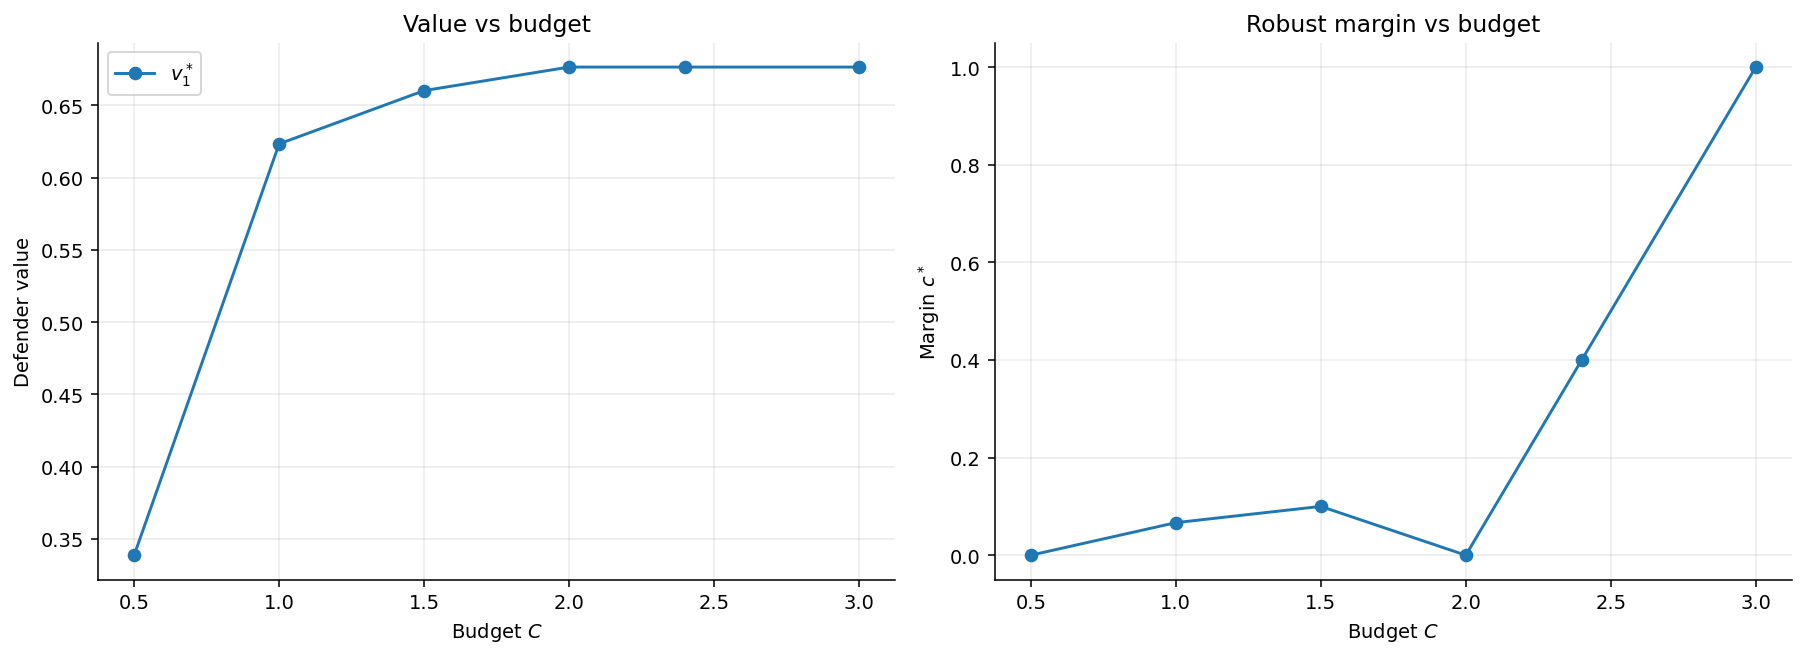

In [10]:
def build_budget_sweep_df(case_name: str = 'paper_style_attack_graph', time_limit: int = 60):
    if BUDGET_JSON.exists() and case_name == 'paper_style_attack_graph':
        with open(BUDGET_JSON, 'r', encoding='utf-8') as f:
            data = json.load(f)
        return pd.DataFrame(data)
    base_mdp = get_case_mdp(case_name)
    budgets = [round(x, 2) for x in np.linspace(max(0.5, 0.25 * base_mdp.budget), 1.4 * base_mdp.budget, 8)]
    rows = []
    for B in budgets:
        mdp = base_mdp.with_budget(B)
        std = solve_standard_reward_design(mdp, time_limit_seconds=time_limit)
        rob = solve_max_margin_reward_design(mdp, v1_star=std.v1_star, time_limit_seconds=time_limit)
        std_vals = optimistic_and_pessimistic_values(mdp, std.x_milp)
        rob_vals = optimistic_and_pessimistic_values(mdp, rob.x_ip)
        rows.append({
            'budget': B,
            'v1_star': std.v1_star,
            'standard_pessimistic_value': std_vals.defender_pessimistic_value,
            'robust_pessimistic_value': rob_vals.defender_pessimistic_value,
            'c_star': rob.c_star,
            'standard_runtime_seconds': std.runtime_seconds,
            'robust_runtime_seconds': rob.runtime_seconds,
        })
    return pd.DataFrame(rows)

budget_df = build_budget_sweep_df()
budget_df.to_csv(DATA_DIR / 'budget_sweep_recomputed.csv', index=False)
display(budget_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(budget_df['budget'], budget_df['v1_star'], marker='o', label='$v_1^*$')
if 'standard_pessimistic_value' in budget_df:
    axes[0].plot(budget_df['budget'], budget_df['standard_pessimistic_value'], marker='s', label='standard pess')
if 'robust_pessimistic_value' in budget_df:
    axes[0].plot(budget_df['budget'], budget_df['robust_pessimistic_value'], marker='^', label='robust pess')
axes[0].set_xlabel('Budget $C$')
axes[0].set_ylabel('Defender value')
axes[0].set_title('Value vs budget')
axes[0].legend()

axes[1].plot(budget_df['budget'], budget_df['c_star'], marker='o')
axes[1].set_xlabel('Budget $C$')
axes[1].set_ylabel('Margin $c^*$')
axes[1].set_title('Robust margin vs budget')

savefig('fig07_budget_sweep.png')
plt.show()


## 8. Tau sweep: bounded rationality sweep cho các case nhỏ

,case_name,mode,tau,defender_value,true_goal_probability,decoy_probability
0,paper_style_attack_graph,standard,0.005,0.552605,0.355469,0.644531
1,paper_style_attack_graph,robust,0.005,0.675339,0.212318,0.787682
2,paper_style_attack_graph,standard,0.010,0.552605,0.355469,0.644531
3,paper_style_attack_graph,robust,0.010,0.672377,0.215772,0.784228
4,paper_style_attack_graph,standard,0.020,0.552605,0.355469,0.644531


Saved: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\paper_notebook_outputs\figures\fig08_tau_sweep_all_cases.png


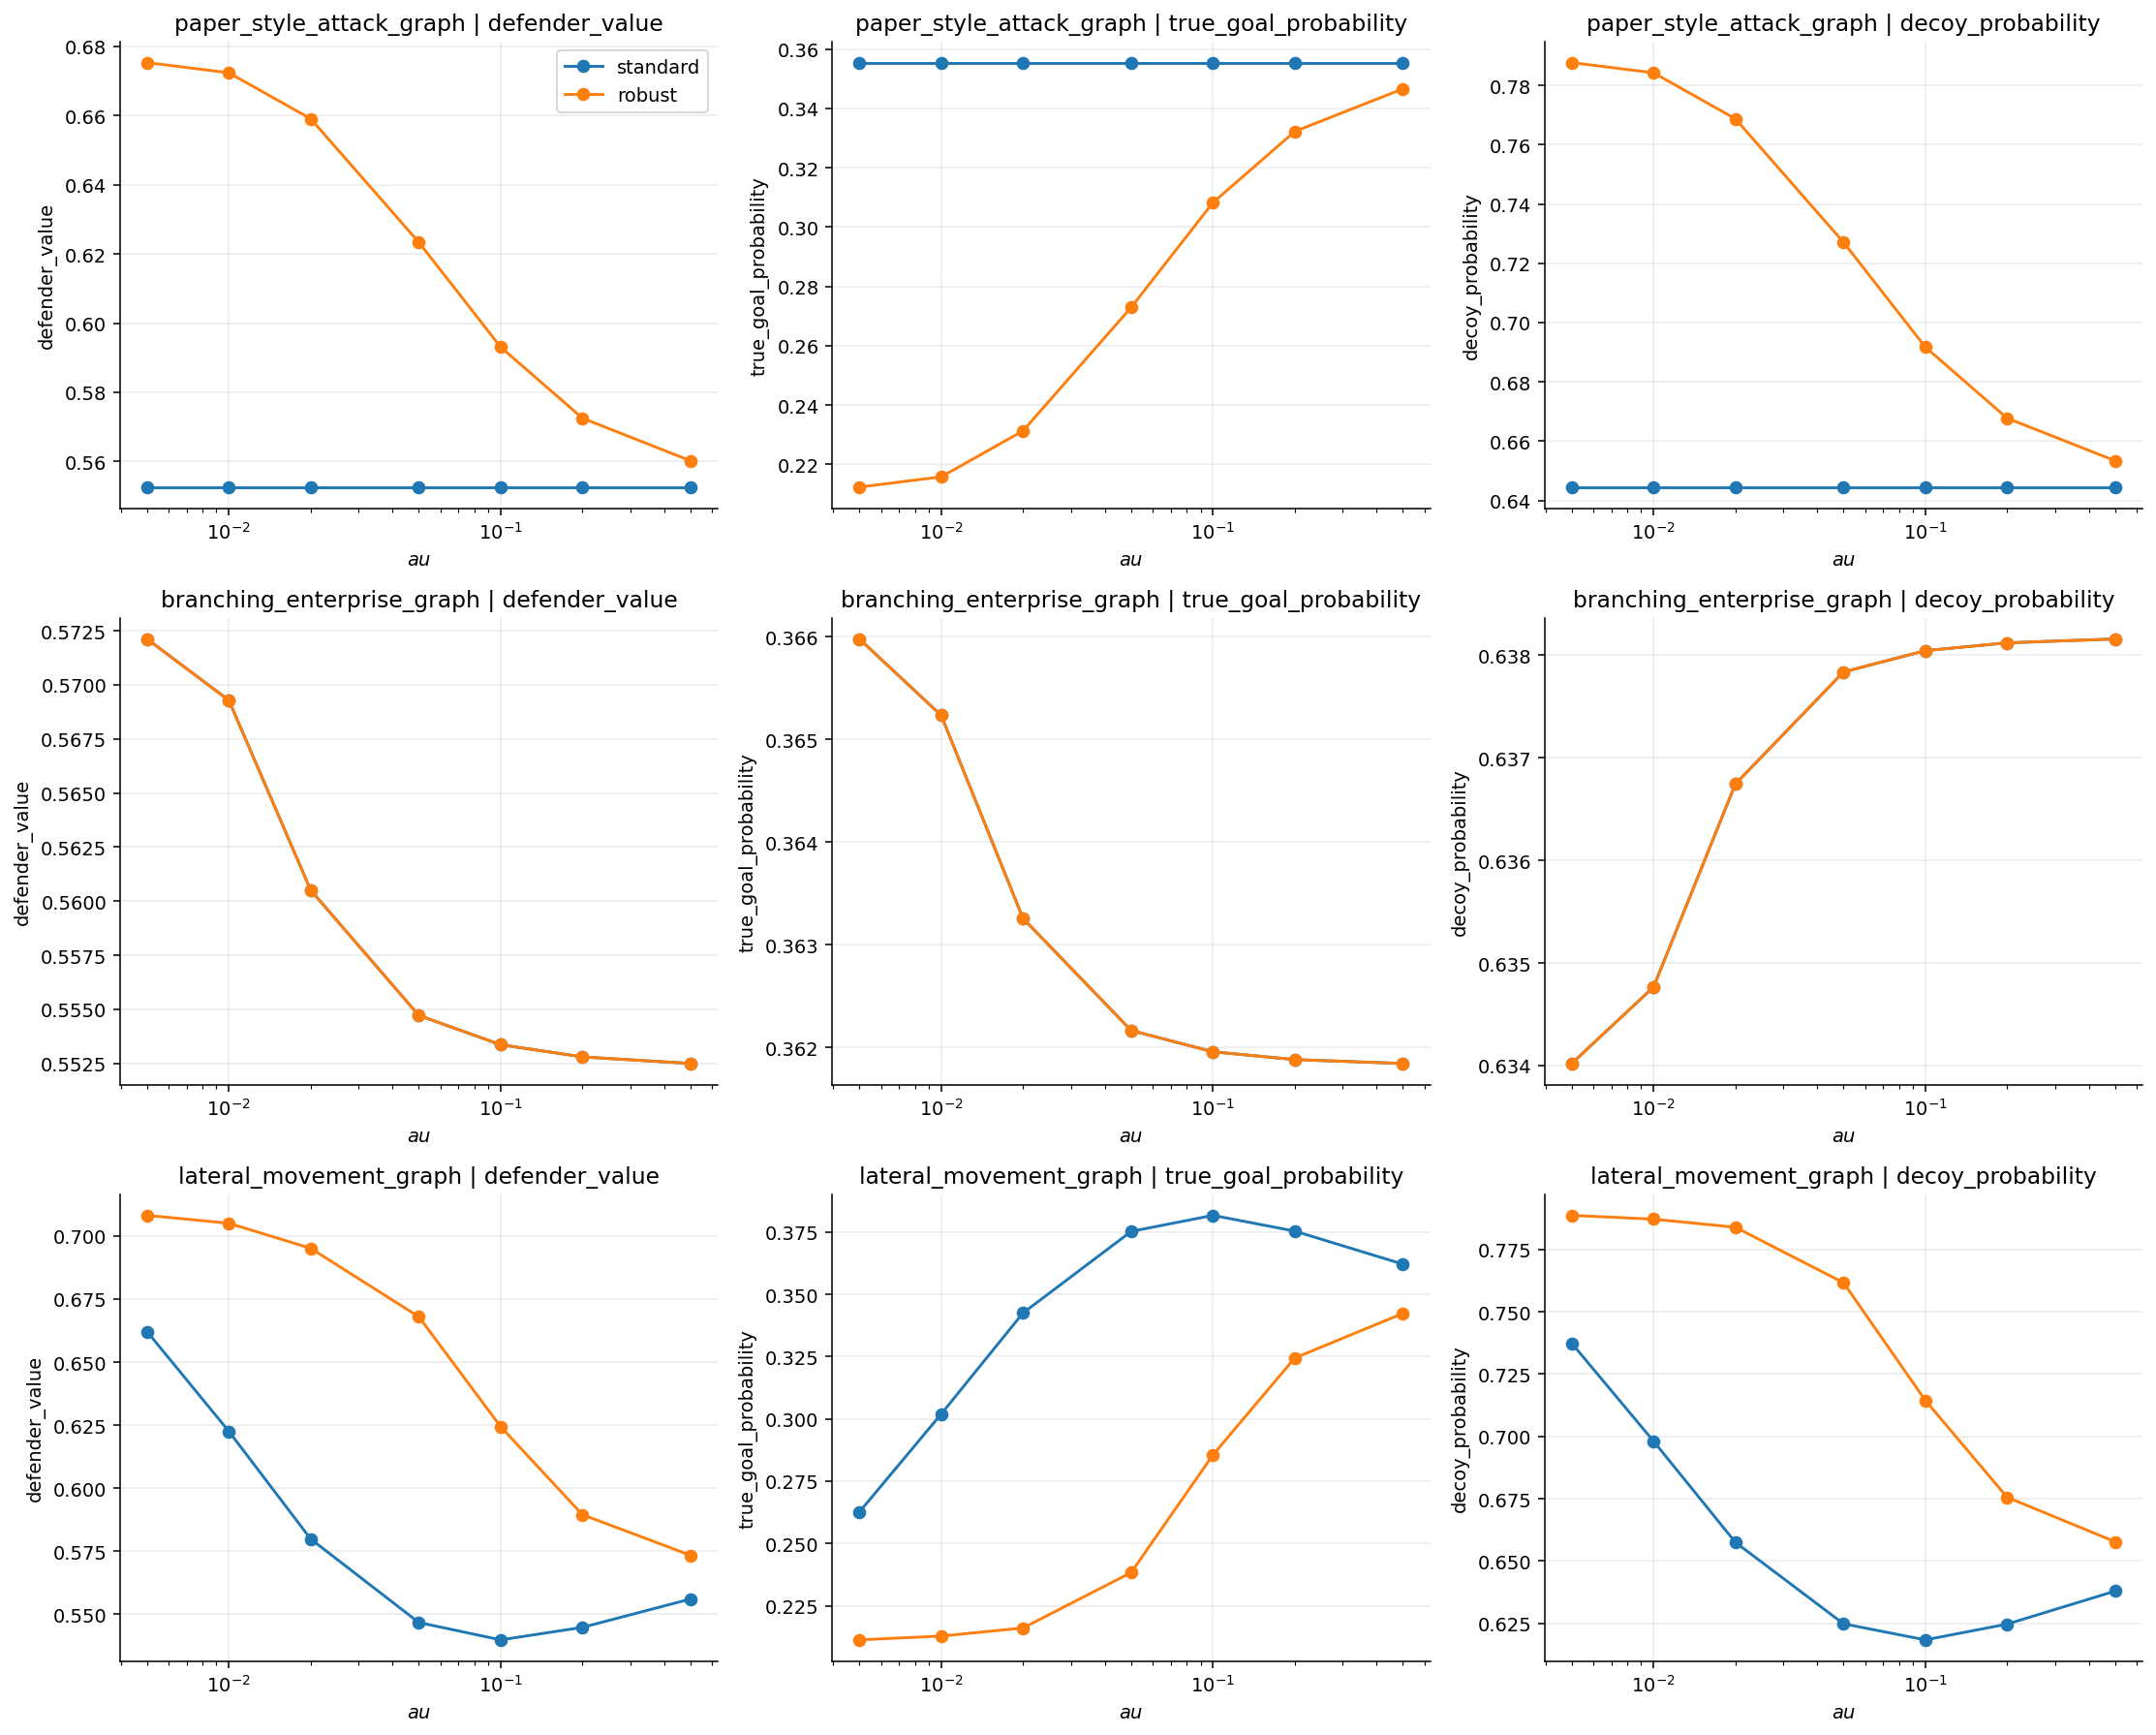

In [11]:
def build_tau_sweep_df(case_names=None, taus=None, time_limit: int = 60):
    if case_names is None:
        case_names = case_order
    if taus is None:
        taus = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
    rows = []
    for case_name in case_names:
        mdp = get_case_mdp(case_name)
        std = solve_standard_reward_design(mdp, time_limit_seconds=time_limit)
        rob = solve_max_margin_reward_design(mdp, v1_star=std.v1_star, time_limit_seconds=time_limit)
        for tau in taus:
            std_soft = soft_response_summary(mdp, std.x_milp, tau=tau)
            rob_soft = soft_response_summary(mdp, rob.x_ip, tau=tau)
            rows.extend([
                {
                    'case_name': case_name, 'mode': 'standard', 'tau': tau,
                    'defender_value': std_soft.defender_value,
                    'true_goal_probability': std_soft.true_goal_probability,
                    'decoy_probability': std_soft.decoy_probability,
                },
                {
                    'case_name': case_name, 'mode': 'robust', 'tau': tau,
                    'defender_value': rob_soft.defender_value,
                    'true_goal_probability': rob_soft.true_goal_probability,
                    'decoy_probability': rob_soft.decoy_probability,
                },
            ])
    return pd.DataFrame(rows)

tau_df = cache_csv(DATA_DIR / 'tau_sweep.csv', build_tau_sweep_df)
display(tau_df.head())

fig, axes = plt.subplots(len(case_order), 3, figsize=(16, 4.3 * len(case_order)))
if len(case_order) == 1:
    axes = np.array([axes])
for r, case_name in enumerate(case_order):
    subset = tau_df[tau_df['case_name'] == case_name]
    for c, metric in enumerate(['defender_value', 'true_goal_probability', 'decoy_probability']):
        ax = axes[r, c]
        for mode in ['standard', 'robust']:
            ss = subset[subset['mode'] == mode]
            ax.plot(ss['tau'], ss[metric], marker='o', label=mode)
        ax.set_xscale('log')
        ax.set_title(f'{case_name} | {metric}')
        ax.set_xlabel('$\tau$')
        ax.set_ylabel(metric)
        if r == 0 and c == 0:
            ax.legend()

savefig('fig08_tau_sweep_all_cases.png')
plt.show()


## 9. Reward-perception perturbation sweep theo chuẩn $L_1$

<>:37: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
C:\Users\DELL\AppData\Local\Temp\ipykernel_37476\2135839803.py:37: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('$\epsilon$ (L1 perturbation radius)')


,case_name,mode,epsilon,best_pessimistic_value,worst_pessimistic_value,avg_pessimistic_value
0,paper_style_attack_graph,standard,0.00,0.329232,0.329232,0.329232
1,paper_style_attack_graph,standard,0.02,0.676460,0.329232,0.580336
2,paper_style_attack_graph,standard,0.05,0.676465,0.329232,0.594795
3,paper_style_attack_graph,standard,0.10,0.676467,0.329232,0.499158
4,paper_style_attack_graph,standard,0.20,0.676468,0.329232,0.568352


Saved: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\paper_notebook_outputs\figures\fig09_reward_perception_sweep.png


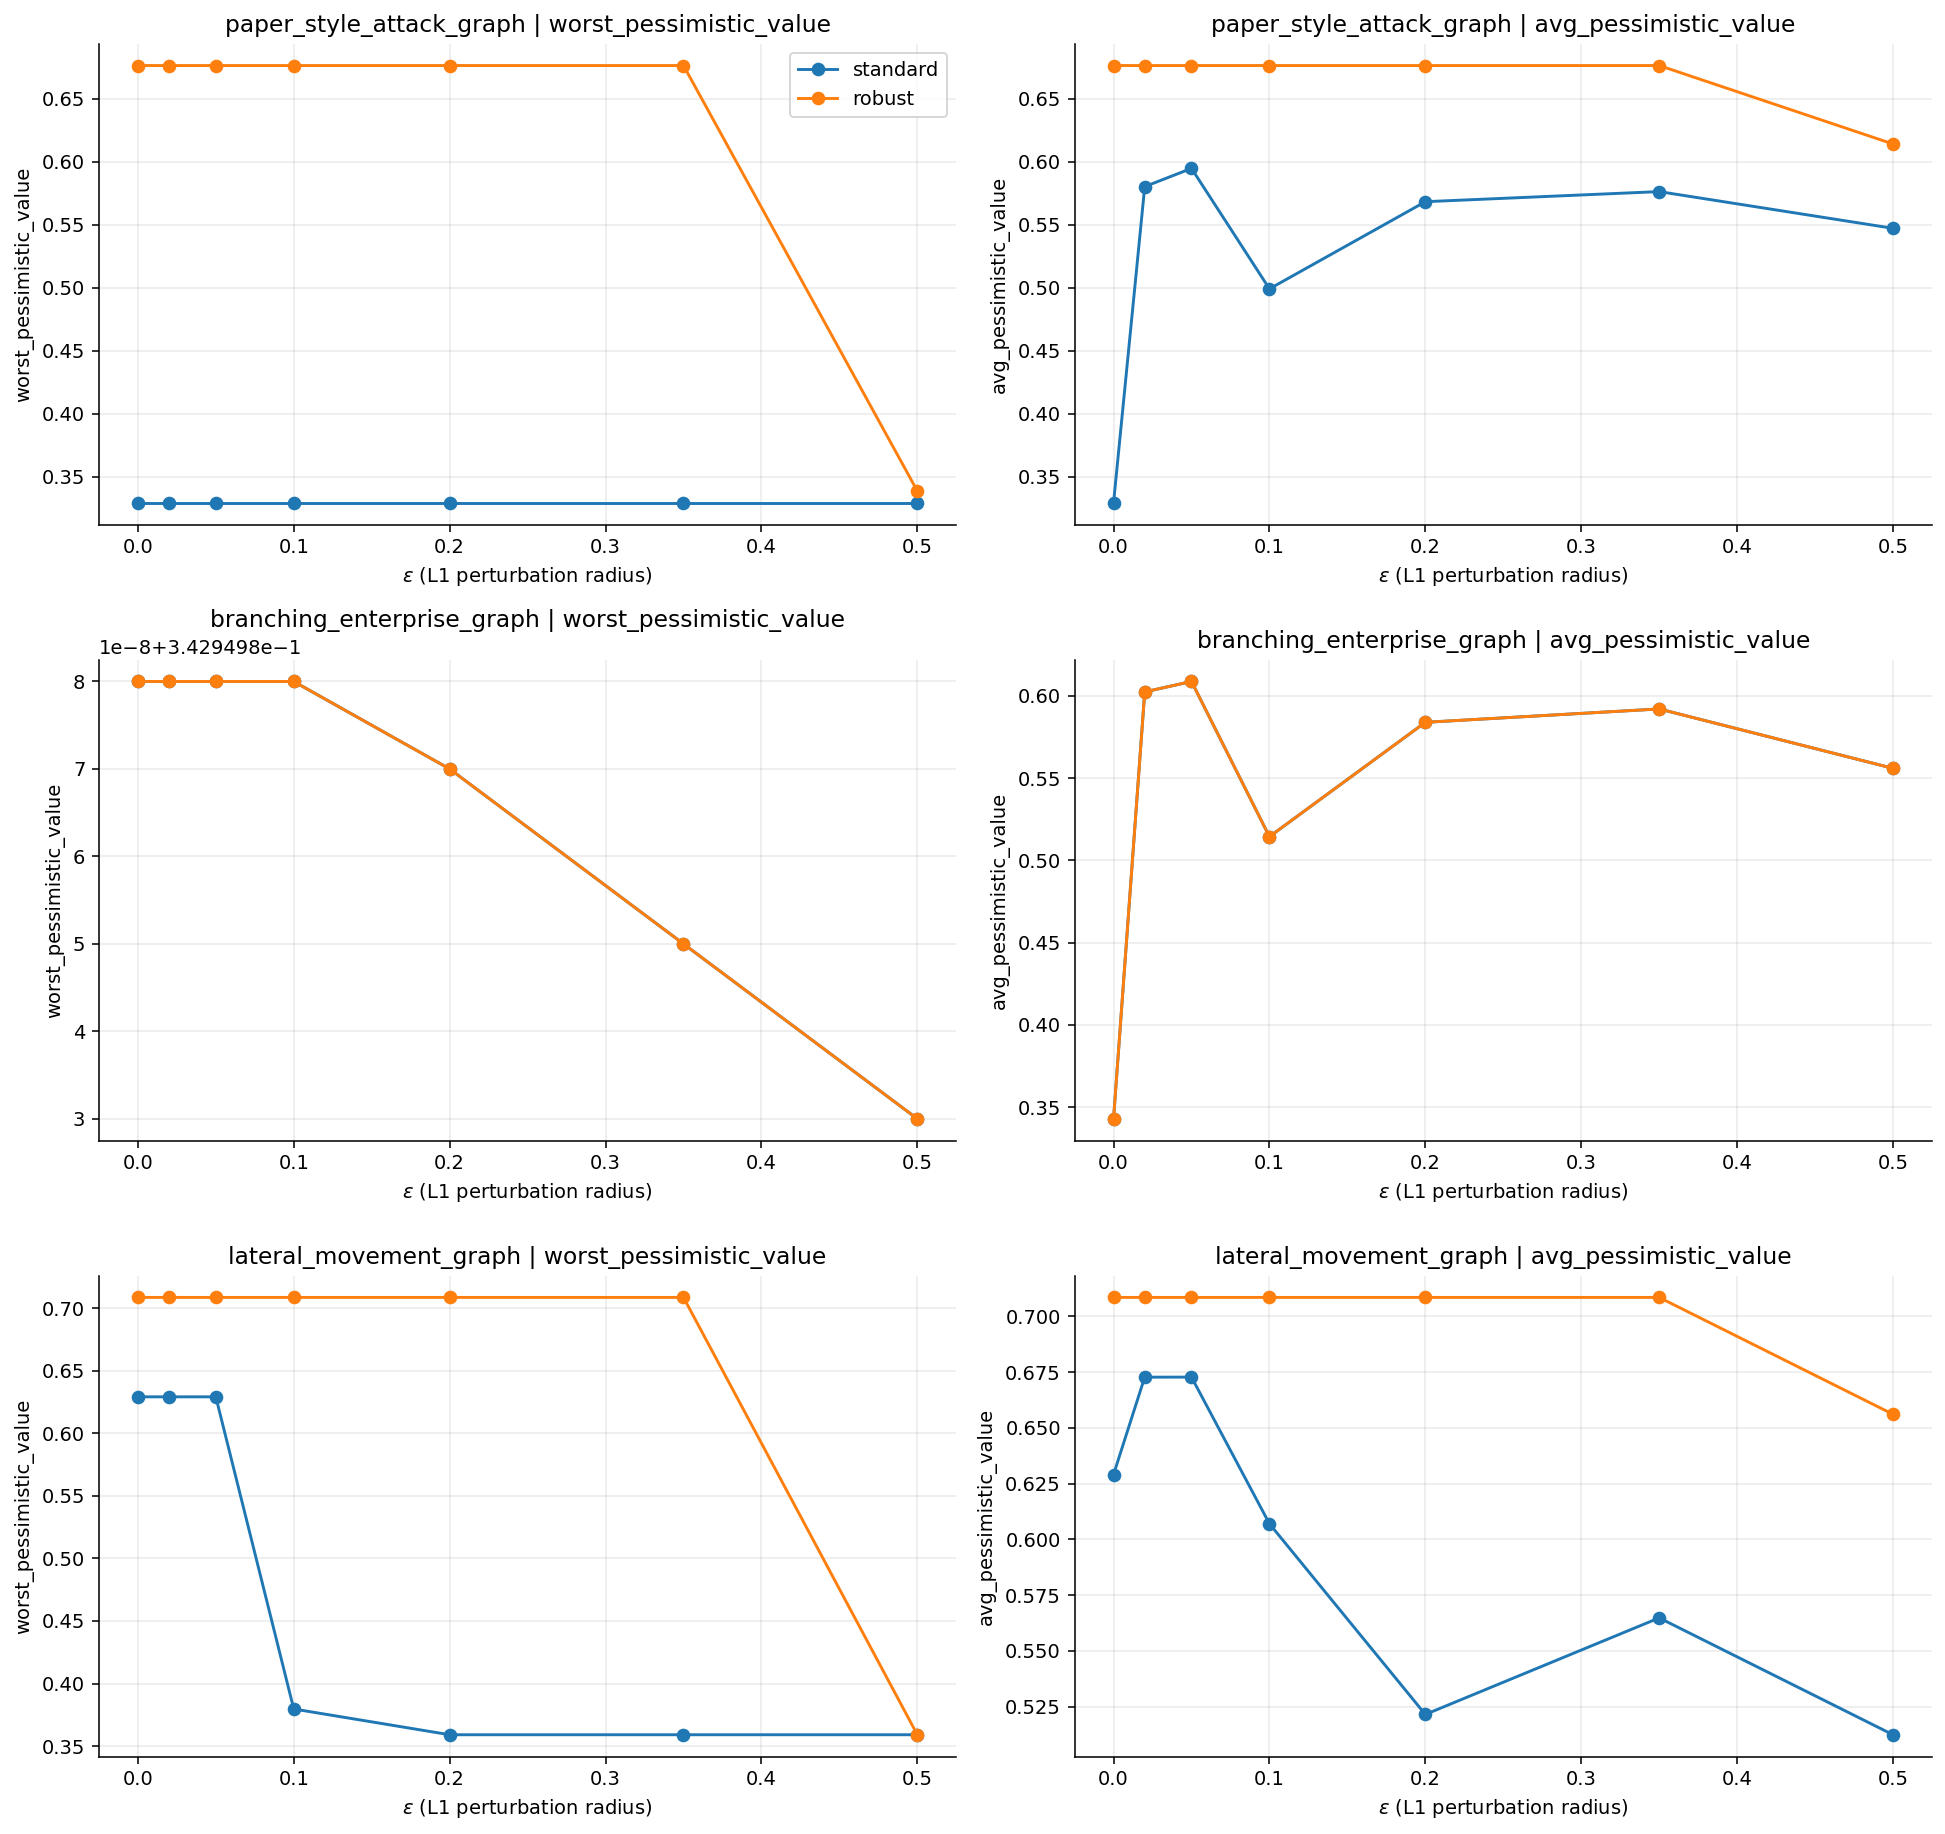

In [12]:
def build_reward_sweep_df(case_names=None, epsilons=None, time_limit: int = 60):
    if case_names is None:
        case_names = case_order
    if epsilons is None:
        epsilons = [0.0, 0.02, 0.05, 0.10, 0.20, 0.35, 0.50]
    rows = []
    for case_name in case_names:
        mdp = get_case_mdp(case_name)
        std = solve_standard_reward_design(mdp, time_limit_seconds=time_limit)
        rob = solve_max_margin_reward_design(mdp, v1_star=std.v1_star, time_limit_seconds=time_limit)
        for mode, alloc in [('standard', std.x_milp), ('robust', rob.x_ip)]:
            sweep = reward_perception_sweep(mdp, alloc, epsilons=epsilons, samples_per_epsilon=20, seed=7)
            for item in sweep:
                rows.append({
                    'case_name': case_name,
                    'mode': mode,
                    'epsilon': item.epsilon,
                    'best_pessimistic_value': item.best_pessimistic_value,
                    'worst_pessimistic_value': item.worst_pessimistic_value,
                    'avg_pessimistic_value': item.avg_pessimistic_value,
                })
    return pd.DataFrame(rows)

pert_df = cache_csv(DATA_DIR / 'reward_perception_sweep.csv', build_reward_sweep_df)
display(pert_df.head())

fig, axes = plt.subplots(len(case_order), 2, figsize=(14, 4.4 * len(case_order)))
if len(case_order) == 1:
    axes = np.array([axes])
for r, case_name in enumerate(case_order):
    subset = pert_df[pert_df['case_name'] == case_name]
    for c, metric in enumerate(['worst_pessimistic_value', 'avg_pessimistic_value']):
        ax = axes[r, c]
        for mode in ['standard', 'robust']:
            ss = subset[subset['mode'] == mode]
            ax.plot(ss['epsilon'], ss[metric], marker='o', label=mode)
        ax.set_xlabel('$\epsilon$ (L1 perturbation radius)')
        ax.set_ylabel(metric)
        ax.set_title(f'{case_name} | {metric}')
        if r == 0 and c == 0:
            ax.legend()

savefig('fig09_reward_perception_sweep.png')
plt.show()


## 10. Intervention ranking cho graph lớn

Saved: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\paper_notebook_outputs\figures\fig10_intervention_ranking_large_graphs.png


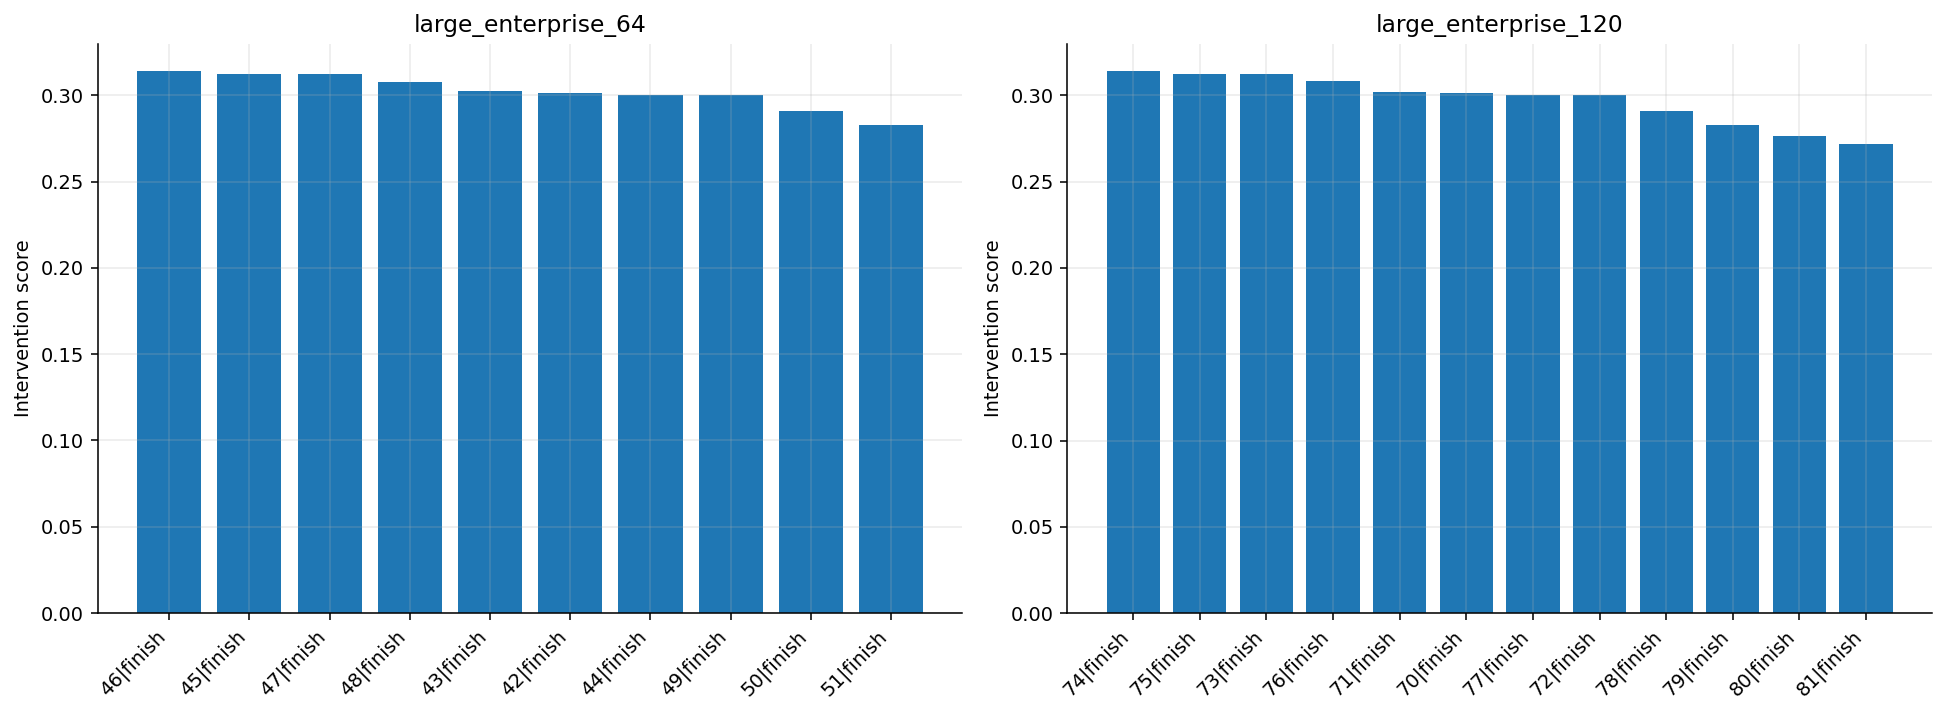

In [13]:
fig, axes = plt.subplots(1, len(LARGE_CASES), figsize=(7 * len(LARGE_CASES), 5.2))
if len(LARGE_CASES) == 1:
    axes = [axes]
for ax, cfg_name in zip(axes, LARGE_CASES):
    mdp = load_mdp(ROOT / 'configs' / cfg_name)
    scores = score_interventions(mdp)[:12]
    labels = [f'{s.pair[0]}|{s.pair[1]}' for s in scores]
    vals = [s.score for s in scores]
    ax.bar(np.arange(len(labels)), vals)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Intervention score')
    ax.set_title(mdp.name)

savefig('fig10_intervention_ranking_large_graphs.png')
plt.show()


## 11. Scalability + quality trade-off cho graph lớn

Saved: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\paper_notebook_outputs\figures\fig11_large_graph_quality_tradeoff.png


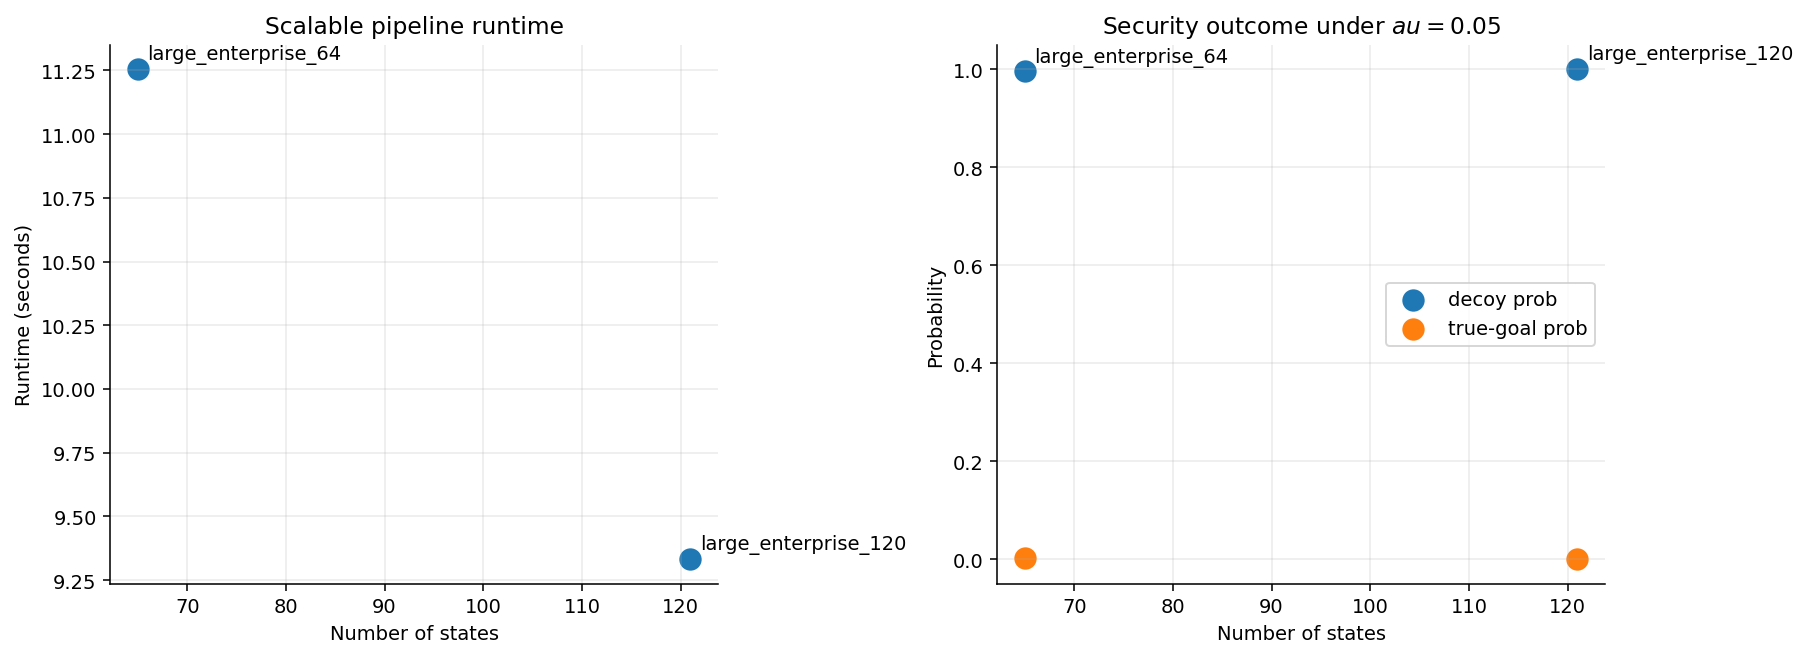

In [14]:
large_df = bench_df[bench_df['mode'] == 'scalable_heuristic'].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].scatter(large_df['num_states'], large_df['runtime_seconds'], s=110)
for _, row in large_df.iterrows():
    axes[0].annotate(row['case_name'], (row['num_states'], row['runtime_seconds']), xytext=(5, 5), textcoords='offset points')
axes[0].set_xlabel('Number of states')
axes[0].set_ylabel('Runtime (seconds)')
axes[0].set_title('Scalable pipeline runtime')

axes[1].scatter(large_df['num_states'], large_df['tau05_decoy_prob'], s=110, label='decoy prob')
axes[1].scatter(large_df['num_states'], large_df['tau05_true_goal_prob'], s=110, label='true-goal prob')
for _, row in large_df.iterrows():
    axes[1].annotate(row['case_name'], (row['num_states'], row['tau05_decoy_prob']), xytext=(5, 5), textcoords='offset points')
axes[1].set_xlabel('Number of states')
axes[1].set_ylabel('Probability')
axes[1].set_title('Security outcome under $\tau=0.05$')
axes[1].legend()

savefig('fig11_large_graph_quality_tradeoff.png')
plt.show()


## 12. Bubble summary cho toàn bộ benchmark

Saved: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\paper_notebook_outputs\figures\fig12_benchmark_bubble_summary.png


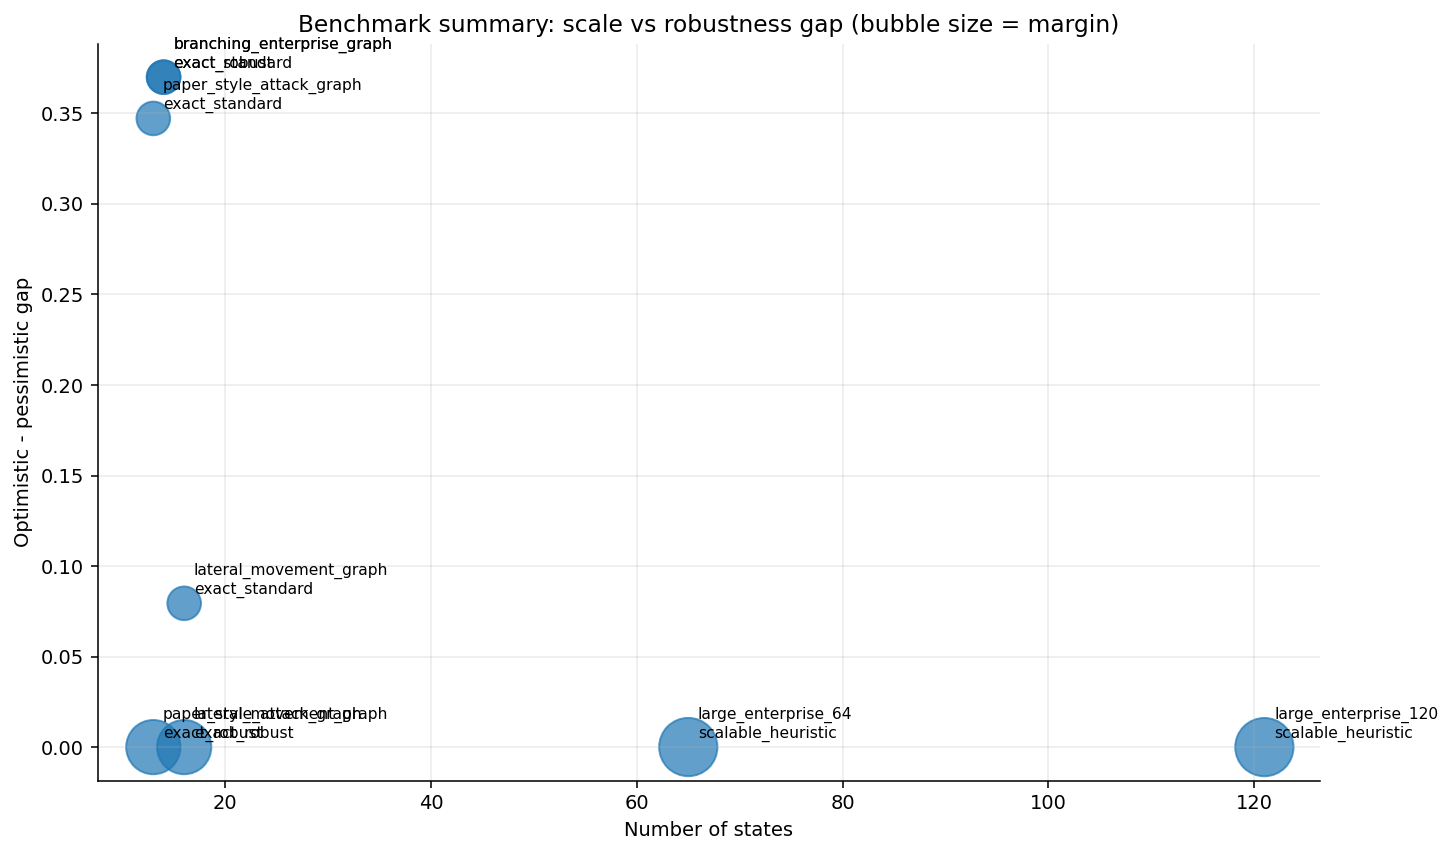

In [15]:
summary_df = bench_df.copy()
summary_df['gap'] = summary_df['optimistic_value'] - summary_df['pessimistic_value']
size = 300 + 1200 * summary_df['margin'].fillna(0.0)
fig, ax = plt.subplots(figsize=(10.5, 6.2))
sc = ax.scatter(summary_df['num_states'], summary_df['gap'], s=size, alpha=0.7)
for _, row in summary_df.iterrows():
    ax.annotate(f"{row['case_name']}\n{row['mode']}", (row['num_states'], row['gap']), xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Number of states')
ax.set_ylabel('Optimistic - pessimistic gap')
ax.set_title('Benchmark summary: scale vs robustness gap (bubble size = margin)')
savefig('fig12_benchmark_bubble_summary.png')
plt.show()


## 13. Kiểm tra và hiển thị architecture figure có sẵn

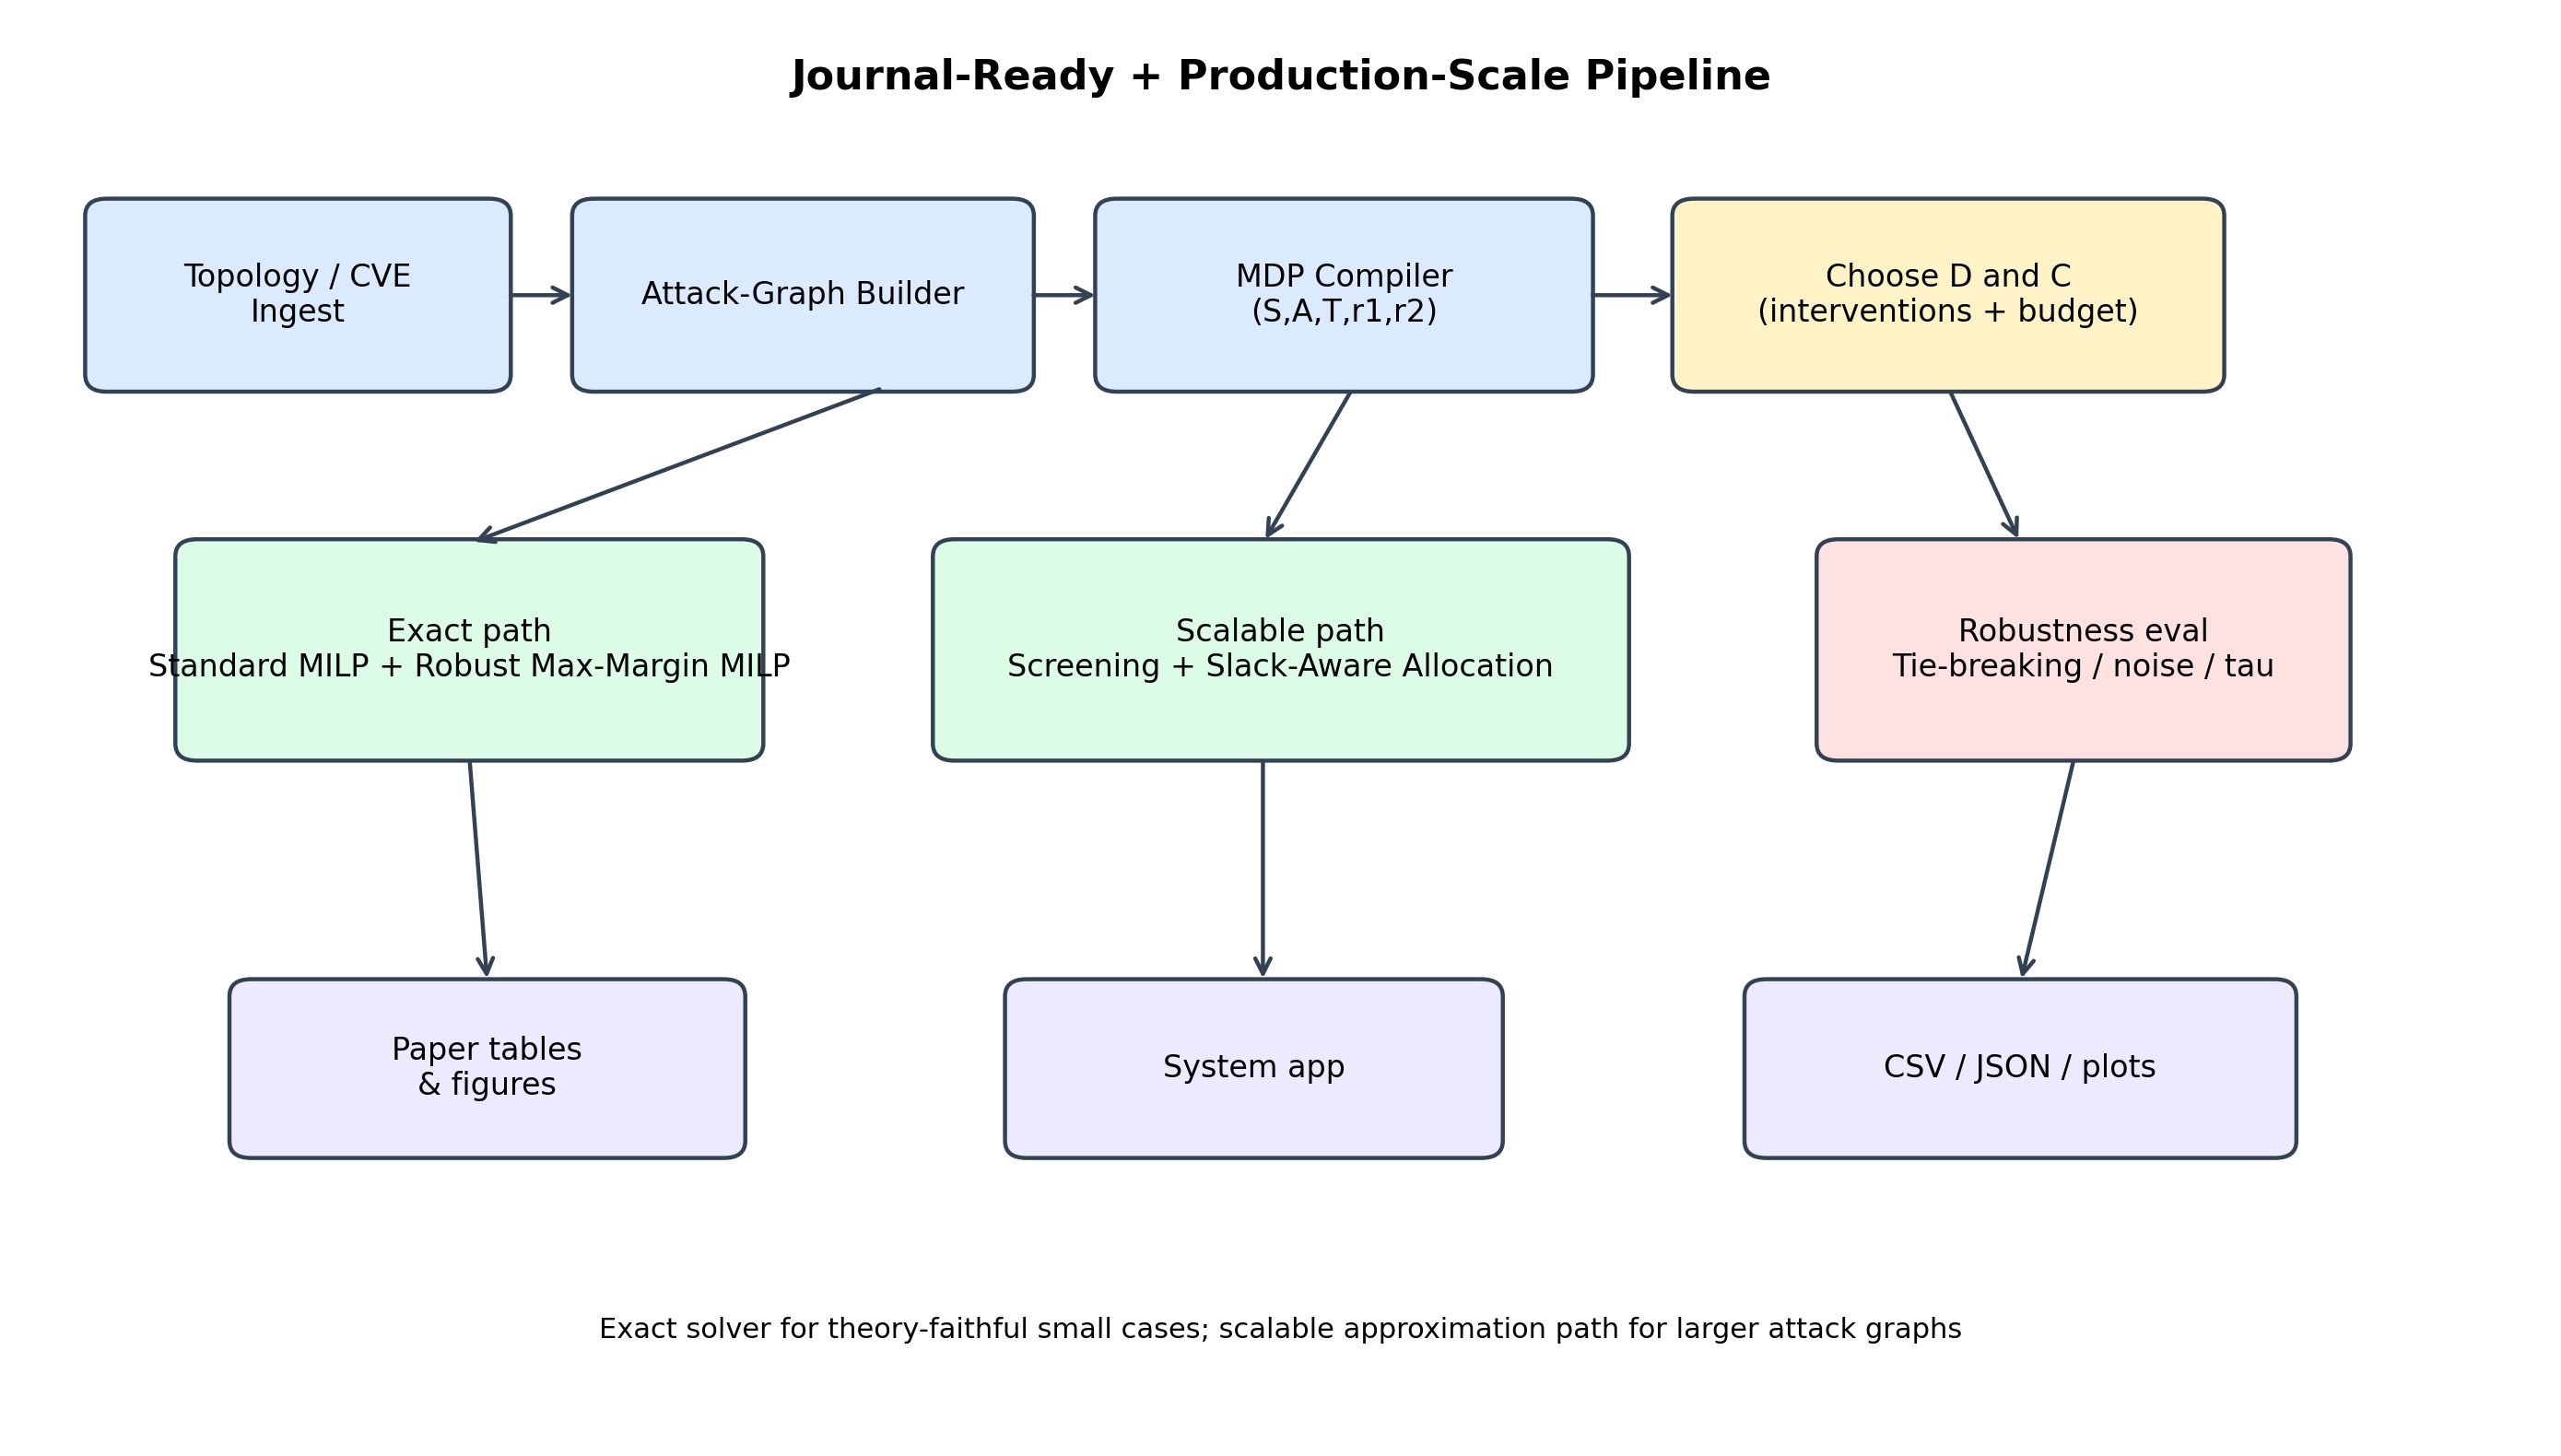

Architecture figure: D:\robust_reward_design_journal_production_suite\robust_reward_design_lab\docs\architecture_figure.png


In [16]:
arch_path = ROOT / 'docs' / 'architecture_figure.png'
if arch_path.exists():
    display(Image(filename=str(arch_path)))
    print('Architecture figure:', arch_path)
else:
    print('Không tìm thấy architecture_figure.png')


## 14. Danh sách output đã sinh

In [17]:
generated = sorted(str(p.relative_to(ROOT)) for p in FIG_DIR.glob('*.png'))
for item in generated:
    print('-', item)


- paper_notebook_outputs\figures\fig01_attack_graph_panel.png
- paper_notebook_outputs\figures\fig02_optimistic_pessimistic_values.png
- paper_notebook_outputs\figures\fig03_gap_and_margin.png
- paper_notebook_outputs\figures\fig04_tau05_goal_vs_decoy.png
- paper_notebook_outputs\figures\fig05_runtime_scaling.png
- paper_notebook_outputs\figures\fig06_allocation_profiles.png
- paper_notebook_outputs\figures\fig07_budget_sweep.png
- paper_notebook_outputs\figures\fig08_tau_sweep_all_cases.png
- paper_notebook_outputs\figures\fig09_reward_perception_sweep.png
- paper_notebook_outputs\figures\fig10_intervention_ranking_large_graphs.png
- paper_notebook_outputs\figures\fig11_large_graph_quality_tradeoff.png
- paper_notebook_outputs\figures\fig12_benchmark_bubble_summary.png
